## Library Imports & Visual Theme Mapping

In [3]:
import logging
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
sns.set_context("paper", font_scale=1.2)
sns.set_palette("tab10")

NOTEBOOK_DIR = Path(".").resolve()
ROOT = NOTEBOOK_DIR.parent
PROCESSED_FILE = ROOT / "data" / "processed" / "processed_dataset.csv"
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f" Workspace configured.\nProcessed File Path: {PROCESSED_FILE}\nFigures Output Target: {FIGURES_DIR}")

 Workspace configured.
Processed File Path: F:\Ayush_Yadav\data\processed\processed_dataset.csv
Figures Output Target: F:\Ayush_Yadav\figures


## Dataset Loading & Stationarity Diagnostics

In [4]:
if not PROCESSED_FILE.exists():
    raise FileNotFoundError(f"Missing processed array at {PROCESSED_FILE}. Run qa_preprocessing.py first.")

df = pd.read_csv(PROCESSED_FILE, index_col="datetime", parse_dates=True)

print(f" Matrix Dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f" Chronological Boundaries: {df.index.min()} ──> {df.index.max()}")
print(f" Negative Price Instances: {(df['price_eur_mwh'] < 0).sum()} hours")
print(f" Extreme Pricing Hours (>300 EUR): {(df['price_eur_mwh'] > 300).sum()} hours")
df.head(3)

 Matrix Dimensions: 39,072 rows × 18 columns
 Chronological Boundaries: 2022-01-01 00:00:00 ──> 2026-06-16 23:00:00
 Negative Price Instances: 1682 hours
 Extreme Pricing Hours (>300 EUR): 2435 hours


,price_eur_mwh,biomass_mwh,hydro_mwh,wind_offshore_mwh,wind_onshore_mwh,solar_mwh,lignite_mwh,hard_coal_mwh,gas_gen_mwh,wind_total_mwh,renewable_ratio,gas_share_thermal,load_mwh,temperature_c,wind_speed_ms,ttf_eur_mwh,price_outlier_flag,residual_load
datetime,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,50.05,4232.5,1465.75,5975.50,25570.25,2.0,3562.00,2039.25,3491.50,31545.75,0.8038,0.3840,43915.50,10.07,19.92,70.343002,0,12367.75
2022-01-01 01:00:00,41.33,4220.0,1518.00,5775.25,24318.25,2.0,3546.75,2049.75,3406.75,30093.50,0.7992,0.3784,41535.75,10.55,17.88,70.343002,0,11440.25
2022-01-01 02:00:00,43.22,4222.5,1468.00,5548.00,23169.50,2.0,3495.00,2033.25,3401.50,28717.50,0.7940,0.3809,40480.75,10.58,17.80,70.343002,0,11761.25


## Price Distribution & Tail Risk Overlays

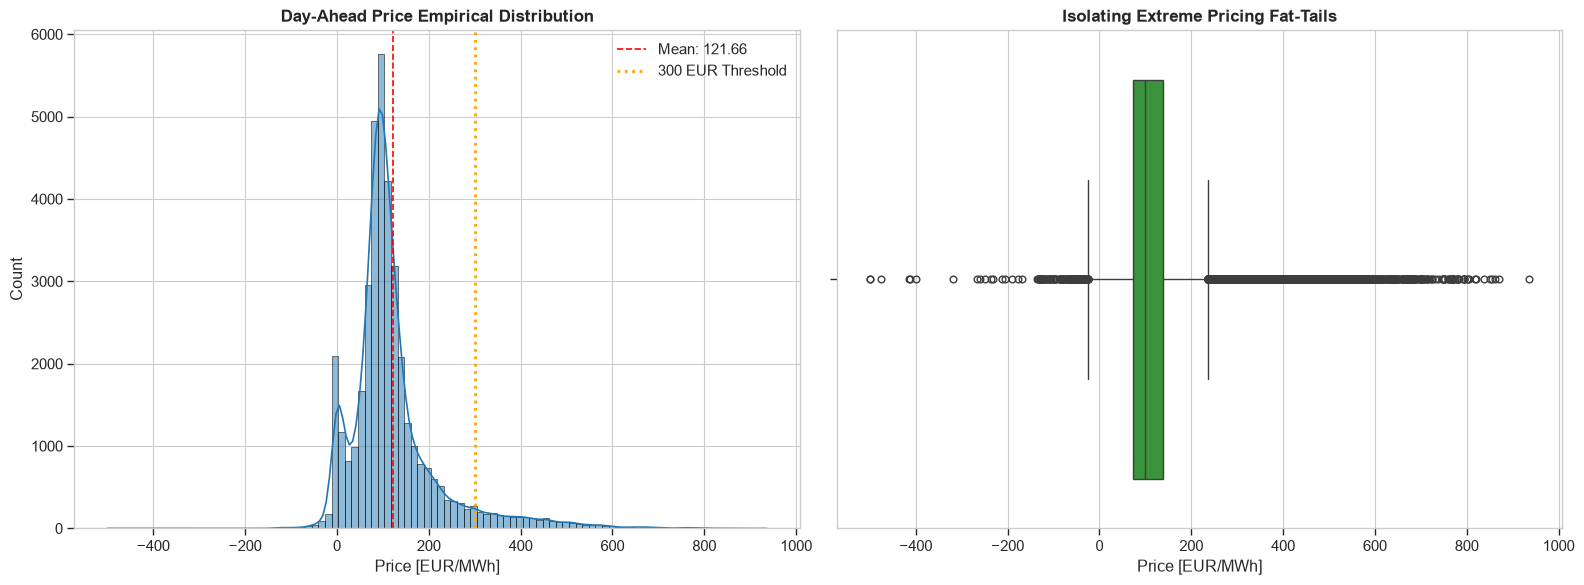

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Histogram with kernel density framework
sns.histplot(df["price_eur_mwh"], bins=100, kde=True, ax=ax[0], color="#1f77b4")
ax[0].axvline(df["price_eur_mwh"].mean(), color="red", linestyle="--", label=f"Mean: {df['price_eur_mwh'].mean():.2f}")
ax[0].axvline(300, color="orange", linestyle=":", linewidth=2, label="300 EUR Threshold")
ax[0].set_title("Day-Ahead Price Empirical Distribution", fontsize=12, fontweight="bold")
ax[0].set_xlabel("Price [EUR/MWh]")
ax[0].legend()

# Boxplot to isolate fat-tails and outliers
sns.boxplot(x=df["price_eur_mwh"], ax=ax[1], color="#2ca02c")
ax[1].set_title("Isolating Extreme Pricing Fat-Tails", fontsize=12, fontweight="bold")
ax[1].set_xlabel("Price [EUR/MWh]")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "price_distribution.png", dpi=300)
plt.show()

## Temporal Micro Profiles (Hourly, Weekday, Monthly)

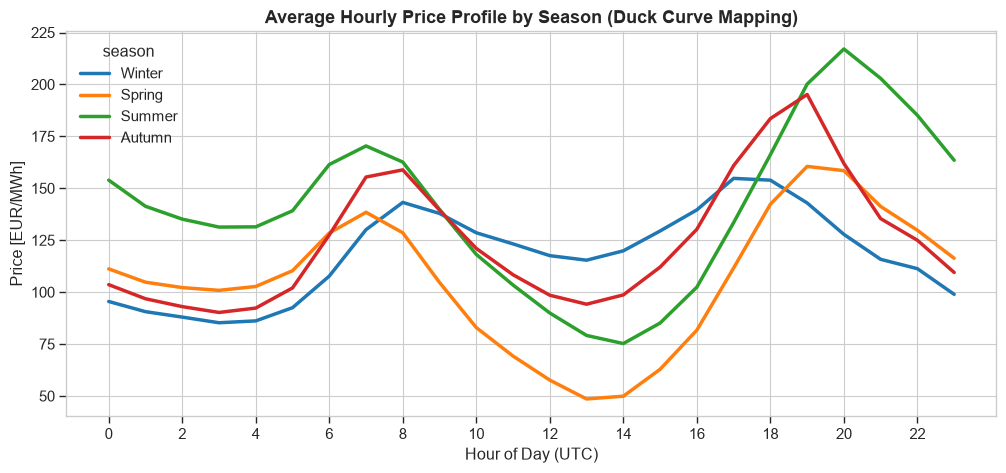

C:\Users\Ayush\AppData\Local\Temp\ipykernel_18600\3180341745.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])


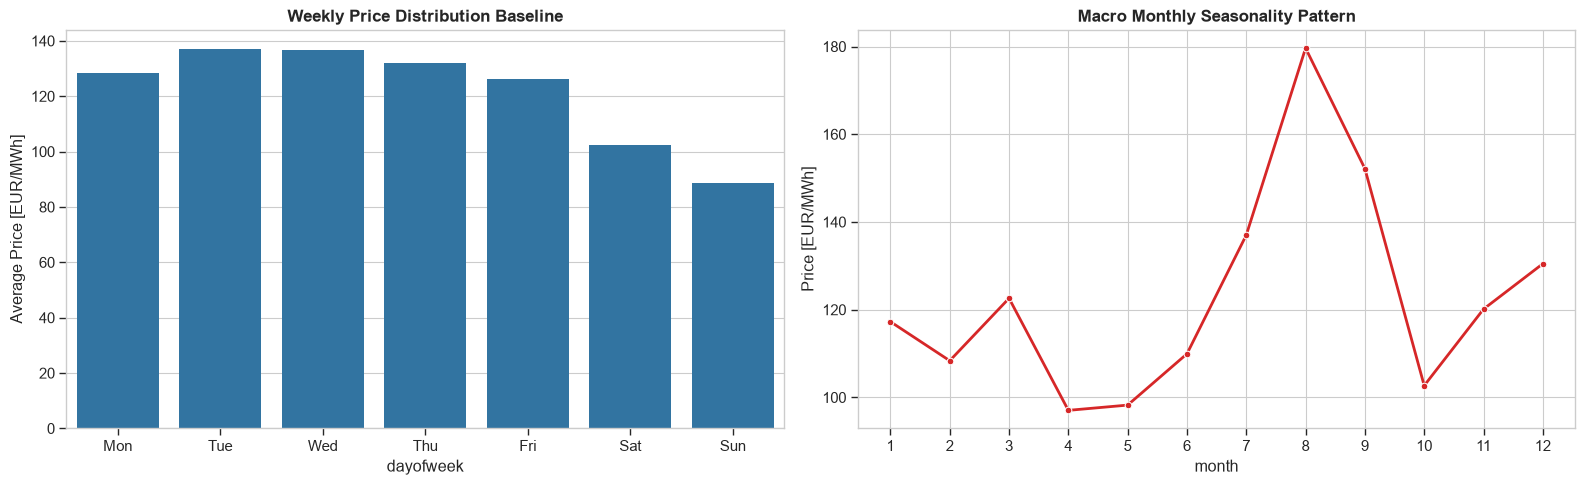

In [6]:
df_time = df.copy()
df_time["hour"] = df_time.index.hour
df_time["dayofweek"] = df_time.index.dayofweek
df_time["month"] = df_time.index.month

# Seasonal Mapping Matrix
df_time["season"] = "Winter"
df_time.loc[df_time["month"].isin([3, 4, 5]), "season"] = "Spring"
df_time.loc[df_time["month"].isin([6, 7, 8]), "season"] = "Summer"
df_time.loc[df_time["month"].isin([9, 10, 11]), "season"] = "Autumn"

# 1. Hourly Duck Curve Check
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_time, x="hour", y="price_eur_mwh", hue="season", linewidth=2.5, errorbar=None)
plt.title("Average Hourly Price Profile by Season (Duck Curve Mapping)", fontsize=13, fontweight="bold")
plt.xlabel("Hour of Day (UTC)")
plt.ylabel("Price [EUR/MWh]")
plt.xticks(range(0, 24, 2))
plt.savefig(FIGURES_DIR / "hourly_profile.png", dpi=300)
plt.show()

# 2. Weekday vs Weekend Slices
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=df_time, x="dayofweek", y="price_eur_mwh", ax=ax[0], color="#1f77b4", errorbar=None)
ax[0].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax[0].set_title("Weekly Price Distribution Baseline", fontsize=12, fontweight="bold")
ax[0].set_ylabel("Average Price [EUR/MWh]")

# 3. Monthly Structural Trend
sns.lineplot(data=df_time, x="month", y="price_eur_mwh", ax=ax[1], marker="o", color="#d62728", linewidth=2, errorbar=None)
ax[1].set_xticks(range(1, 13))
ax[1].set_title("Macro Monthly Seasonality Pattern", fontsize=12, fontweight="bold")
ax[1].set_ylabel("Price [EUR/MWh]")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "temporal_profiles.png", dpi=300)
plt.show()

## Linear Correlation Heatmap

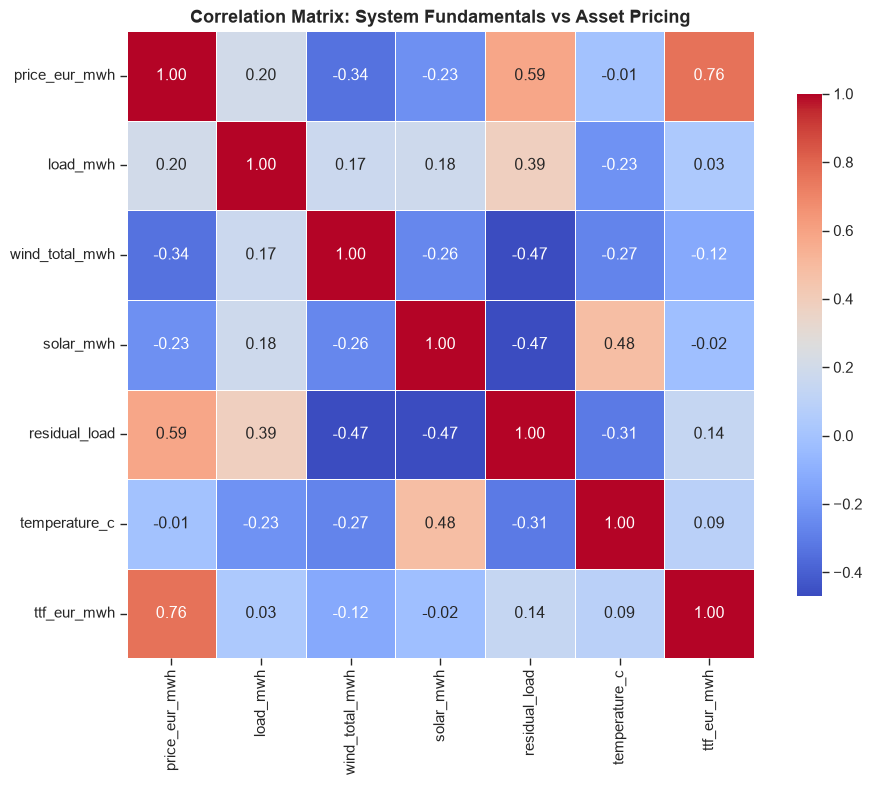

In [7]:
core_cols = [
    "price_eur_mwh", "load_mwh", "wind_total_mwh", "solar_mwh", 
    "residual_load", "temperature_c", "ttf_eur_mwh"
]
valid_cols = [c for c in core_cols if c in df.columns]
corr = df[valid_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix: System Fundamentals vs Asset Pricing", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=300)
plt.show()

## Fundamental Scatter Traces (Wind, Solar, and TTF Gas)

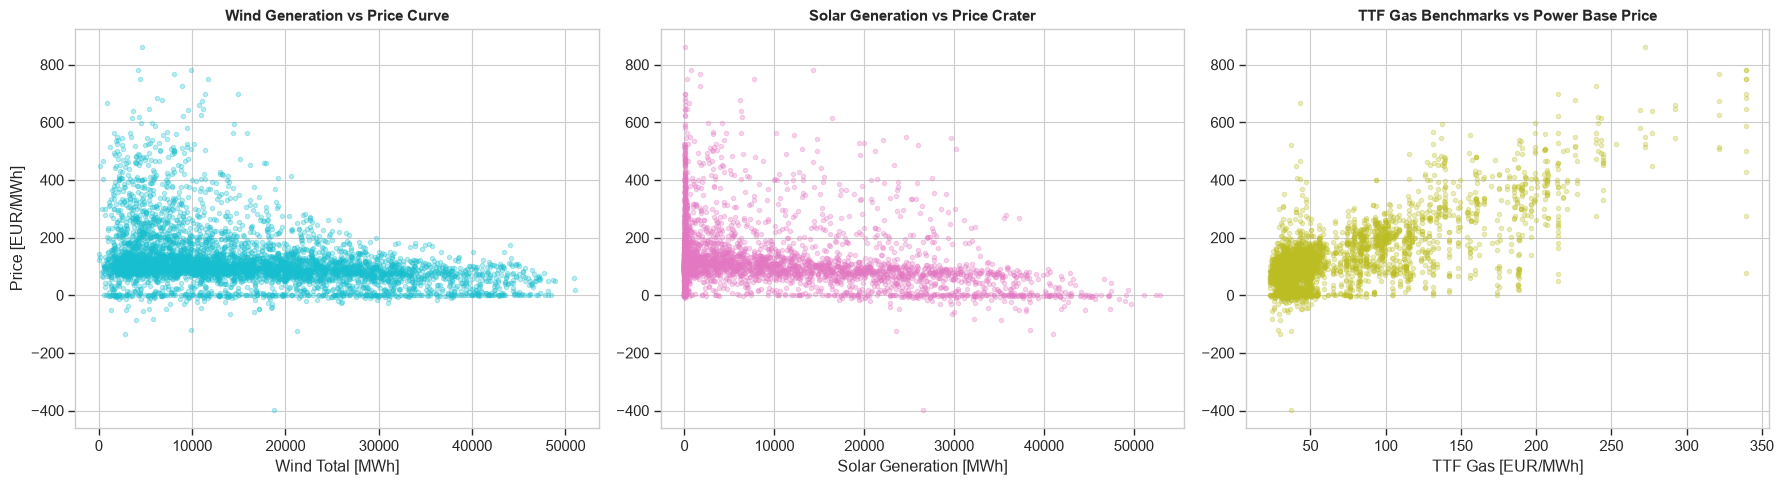

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sample_df = df.sample(n=min(5000, len(df)), random_state=42)

# Wind Impact
ax[0].scatter(sample_df["wind_total_mwh"], sample_df["price_eur_mwh"], alpha=0.3, color="#17becf", s=10)
ax[0].set_title("Wind Generation vs Price Curve", fontsize=11, fontweight="bold")
ax[0].set_xlabel("Wind Total [MWh]")
ax[0].set_ylabel("Price [EUR/MWh]")

# Solar Impact
ax[1].scatter(sample_df["solar_mwh"], sample_df["price_eur_mwh"], alpha=0.3, color="#e377c2", s=10)
ax[1].set_title("Solar Generation vs Price Crater", fontsize=11, fontweight="bold")
ax[1].set_xlabel("Solar Generation [MWh]")

# TTF Gas Fuel Costs Shift
ax[2].scatter(sample_df["ttf_eur_mwh"], sample_df["price_eur_mwh"], alpha=0.3, color="#bcbd22", s=10)
ax[2].set_title("TTF Gas Benchmarks vs Power Base Price", fontsize=11, fontweight="bold")
ax[2].set_xlabel("TTF Gas [EUR/MWh]")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fundamental_scatters.png", dpi=300)
plt.show()

## The Merit-Order Curve Isolation (Residual Load vs Price)

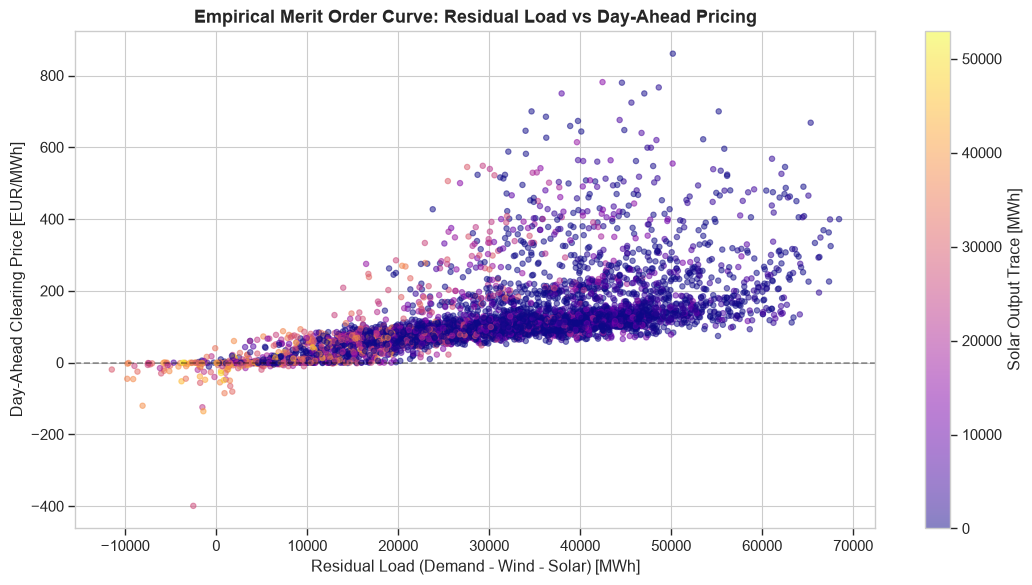

In [9]:
plt.figure(figsize=(11, 6))

# Map color code to Solar to visualize localized daytime shifts along the hockey stick
scatter = plt.scatter(
    sample_df["residual_load"], sample_df["price_eur_mwh"], 
    c=sample_df["solar_mwh"], cmap="plasma", alpha=0.5, s=15
)
cbar = plt.colorbar(scatter)
cbar.set_label("Solar Output Trace [MWh]")

plt.axhline(0, color="black", linestyle="--", alpha=0.4)
plt.title("Empirical Merit Order Curve: Residual Load vs Day-Ahead Pricing", fontsize=13, fontweight="bold")
plt.xlabel("Residual Load (Demand - Wind - Solar) [MWh]")
plt.ylabel("Day-Ahead Clearing Price [EUR/MWh]")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "residual_load_vs_price.png", dpi=300)
plt.show()

## Statistical Percentiles & Outlier Regime Testing

In [10]:
# Calculate statistical boundaries to change the 300 EUR threshold dynamically
quantiles = [0.50, 0.75, 0.90, 0.95, 0.99, 0.995]
price_quantiles = df["price_eur_mwh"].quantile(quantiles)

print(" Day-Ahead Price Percentile Breakdown:")
print("-" * 40)
for q, val in zip(quantiles, price_quantiles):
    print(f"  {q*100:>5.1f}th Percentile : {val:>8.2f} EUR/MWh")
print("-" * 40)

# Calculate the exact threshold where extreme fat-tail behavior starts
p99 = price_quantiles[0.99]
print(f" Statistical Recommendation: Set price_outlier_flag threshold to {round(p99, -1)} EUR/MWh")
print(f"   Hours exceeding this threshold: {(df['price_eur_mwh'] > p99).sum()} hours.")

 Day-Ahead Price Percentile Breakdown:
----------------------------------------
   50.0th Percentile :   100.00 EUR/MWh
   75.0th Percentile :   138.60 EUR/MWh
   90.0th Percentile :   230.32 EUR/MWh
   95.0th Percentile :   334.07 EUR/MWh
   99.0th Percentile :   523.44 EUR/MWh
   99.5th Percentile :   586.51 EUR/MWh
----------------------------------------
 Statistical Recommendation: Set price_outlier_flag threshold to 520.0 EUR/MWh
   Hours exceeding this threshold: 391 hours.


## Auto-Correlation (ACF & PACF) for Lag Determination

In [11]:
!pip install statsmodels


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


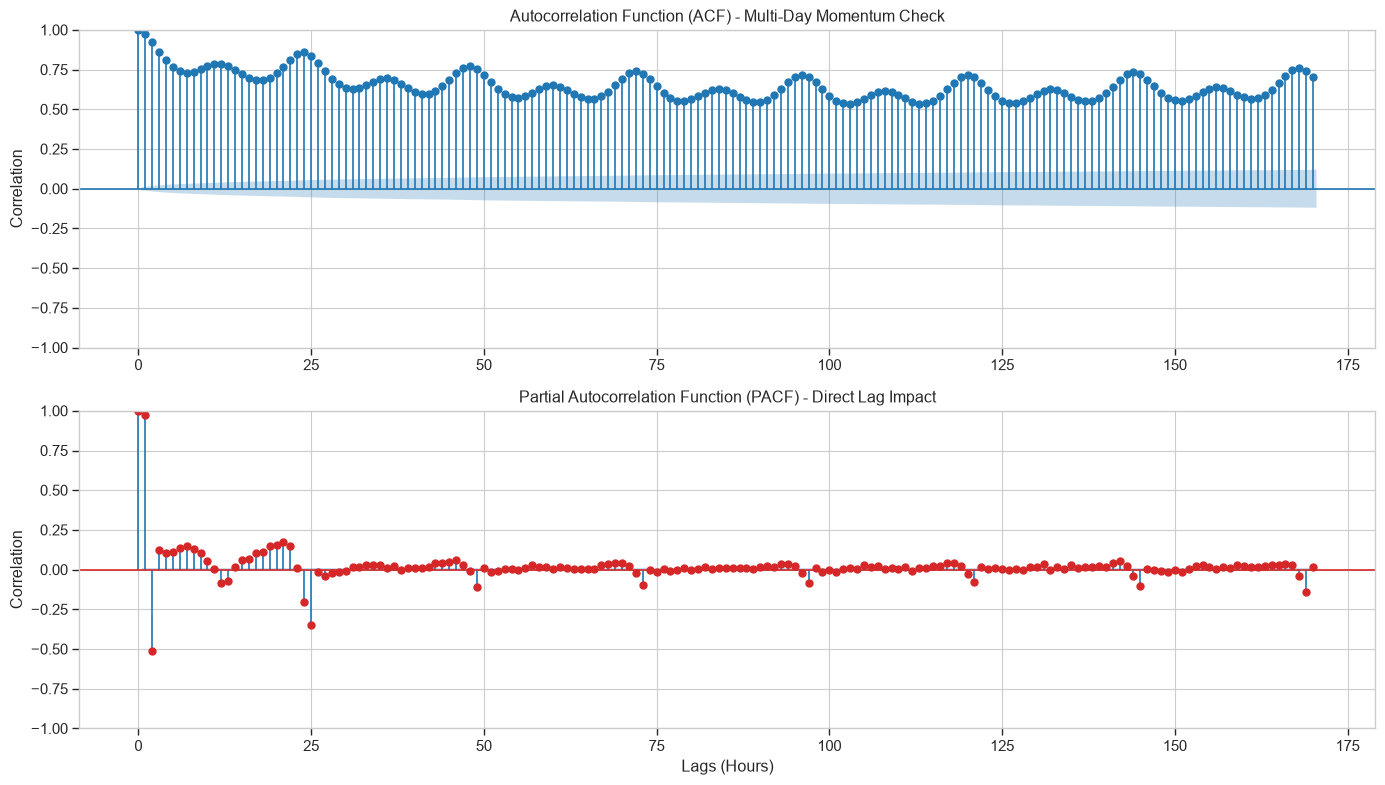

In [12]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Check structural dependencies up to 170 hours (covering a full week lookback)
fig, ax = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(df["price_eur_mwh"], lags=170, ax=ax[0], color="#1f77b4")
ax[0].set_title("Autocorrelation Function (ACF) - Multi-Day Momentum Check")
ax[0].set_ylabel("Correlation")

plot_pacf(df["price_eur_mwh"], lags=170, ax=ax[1], color="#d62728", method="ywm")
ax[1].set_title("Partial Autocorrelation Function (PACF) - Direct Lag Impact")
ax[1].set_xlabel("Lags (Hours)")
ax[1].set_ylabel("Correlation")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "price_acf_pacf.png", dpi=300)
plt.show()

## Negative Prices Regime Clustering Matrix

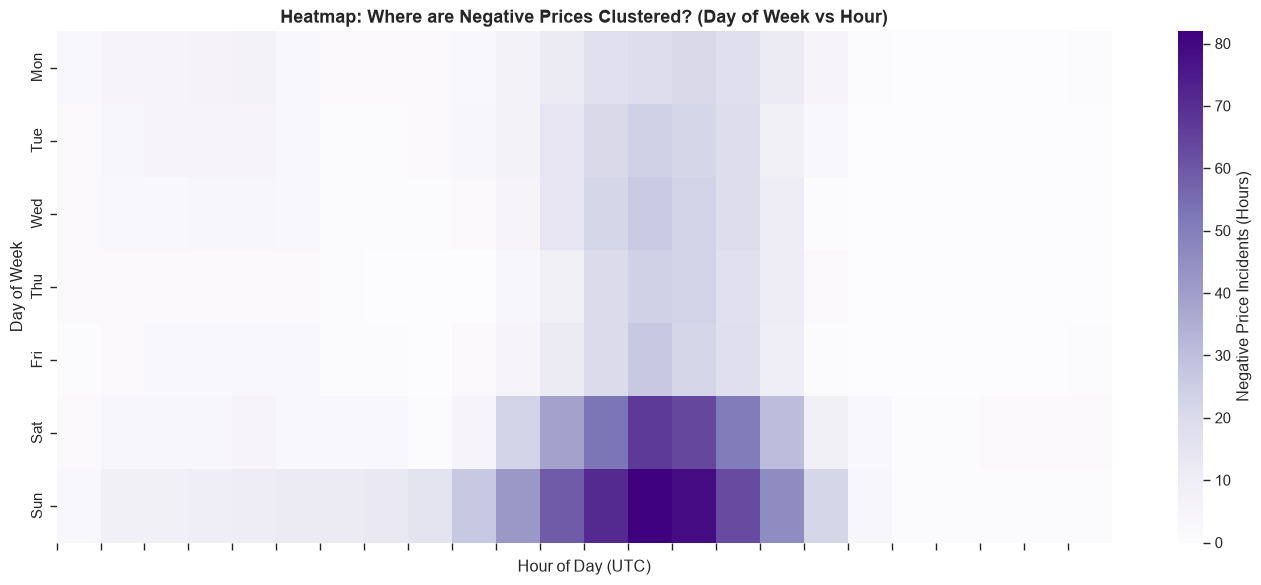

In [13]:
df_neg = df[df["price_eur_mwh"] < 0].copy()
df_neg["hour"] = df_neg.index.hour
df_neg["dayofweek"] = df_neg.index.dayofweek

# Pivot matrix to count negative price occurrences across hours vs days of week
neg_matrix = df_neg.groupby(["dayofweek", "hour"]).size().unstack(fill_value=0)

# Mapping indices to names for clean readability
neg_matrix.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(14, 6))
sns.heatmap(neg_matrix, cmap="Purples", annot=False, cbar_kws={"label": "Negative Price Incidents (Hours)"})
plt.title("Heatmap: Where are Negative Prices Clustered? (Day of Week vs Hour)", fontsize=13, fontweight="bold")
plt.xlabel("Hour of Day (UTC)")
plt.ylabel("Day of Week")
plt.xticks(range(0, 24))
plt.tight_layout()

plt.savefig(FIGURES_DIR / "negative_prices_heatmap.png", dpi=300)
plt.show()

## The Non-Linear Merit Order Slope Differentiation

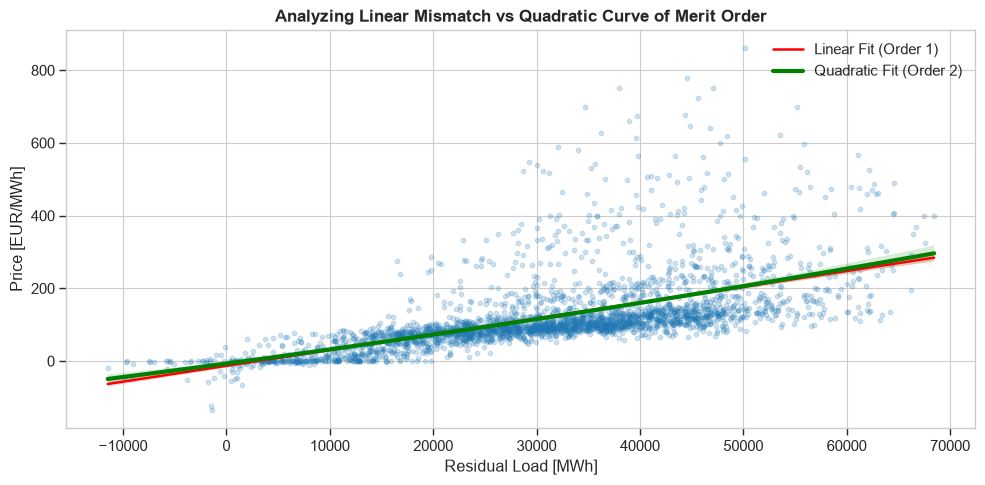

In [14]:
# To prove why we need residual_load_squared feature for Ridge Regression
plt.figure(figsize=(10, 5))

# Fit polynomial order 1 (linear) vs order 2 (quadratic/hockey-stick)
sample_mo = df.sample(n=min(3000, len(df)), random_state=42)
sns.regplot(data=sample_mo, x="residual_load", y="price_eur_mwh", order=1, 
            scatter_kws={"alpha": 0.2, "s": 10}, line_kws={"color": "red", "label": "Linear Fit (Order 1)"})
sns.regplot(data=sample_mo, x="residual_load", y="price_eur_mwh", order=2, 
            scatter_kws={"alpha": 0}, line_kws={"color": "green", "linewidth": 3, "label": "Quadratic Fit (Order 2)"})

plt.title("Analyzing Linear Mismatch vs Quadratic Curve of Merit Order", fontsize=12, fontweight="bold")
plt.xlabel("Residual Load [MWh]")
plt.ylabel("Price [EUR/MWh]")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "merit_order_fit_analysis.png", dpi=300)
plt.show()